In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from sklearn.manifold import TSNE
import umap
from transformers import AutoModel, AutoTokenizer

In [2]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

In [3]:
# ---------------------------------------------------------
# 1. Configuration & Setup
# ---------------------------------------------------------
# Works for roberta-base, vinai/phobert-base-v2, xlm-roberta-base, or your custom model
MODEL_NAME = "roberta-base"
REDUCTION_METHOD = "umap"  # Options: 'tsne' or 'umap'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# output_hidden_states=True forces the model to return hidden states for all layers
model = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True)
model.eval()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=Tru

In [4]:
# ---------------------------------------------------------
# 2. Sample Dataset with Categories
# ---------------------------------------------------------
# Simple labeled text dataset for visualization
data = [
    # Category 0: Sports
    ("The team scored a touchdown in the final quarter.", "Sports"),
    ("The soccer match ended in a dramatic penalty shootout.", "Sports"),
    ("He won the tennis tournament after a tough set.", "Sports"),
    ("The basketball player made a three-point shot.", "Sports"),
    # Category 1: Technology
    ("The neural network was trained on GPU clusters.", "Technology"),
    ("Software updates fixed several critical vulnerabilities.", "Technology"),
    ("Quantum computing could revolutionize cryptography.", "Technology"),
    ("The new smartphone features a high-resolution display.", "Technology"),
    # Category 2: Food & Cooking
    ("Bake the cake at 350 degrees for thirty minutes.", "Food"),
    ("Fresh basil and garlic enhance the pasta sauce.", "Food"),
    ("The chef prepared a gourmet three-course meal.", "Food"),
    ("Stir-fry the vegetables with soy sauce and sesame oil.", "Food"),
]

texts, string_labels = zip(*data)
unique_labels = sorted(list(set(string_labels)))
label_to_id = {label: i for i, label in enumerate(unique_labels)}
y_labels = np.array([label_to_id[label] for label in string_labels])

In [5]:
# ---------------------------------------------------------
# 3. Extract Layer-Wise Hidden Representations
# ---------------------------------------------------------
inputs = tokenizer(
    list(texts), padding=True, truncation=True, return_tensors="pt"
)

with torch.no_grad():
    outputs = model(**inputs)

# outputs.hidden_states is a tuple of (num_layers + 1) tensors
# Each tensor shape: (batch_size, sequence_length, hidden_dim)
hidden_states = outputs.hidden_states
num_layers = len(hidden_states)  # Layer 0 (Embeddings) to Layer 12

# Aggregate representations per sentence (Mean Pooling across non-padding tokens)
attention_mask = inputs["attention_mask"].unsqueeze(-1)  # (batch, seq, 1)

layer_representations = []
for layer_idx in range(num_layers):
    layer_tensor = hidden_states[layer_idx]  # (batch, seq, hidden_dim)
    # Mean-pooling masked by actual token lengths
    sum_embeddings = torch.sum(layer_tensor * attention_mask, dim=1)
    sum_mask = torch.clamp(attention_mask.sum(dim=1), min=1e-9)
    mean_pooled = sum_embeddings / sum_mask  # (batch, hidden_dim)

    layer_representations.append(mean_pooled.numpy())


In [6]:
num_layers

13

/home/phuonglh/miniconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/phuonglh/miniconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/phuonglh/miniconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/phuonglh/miniconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


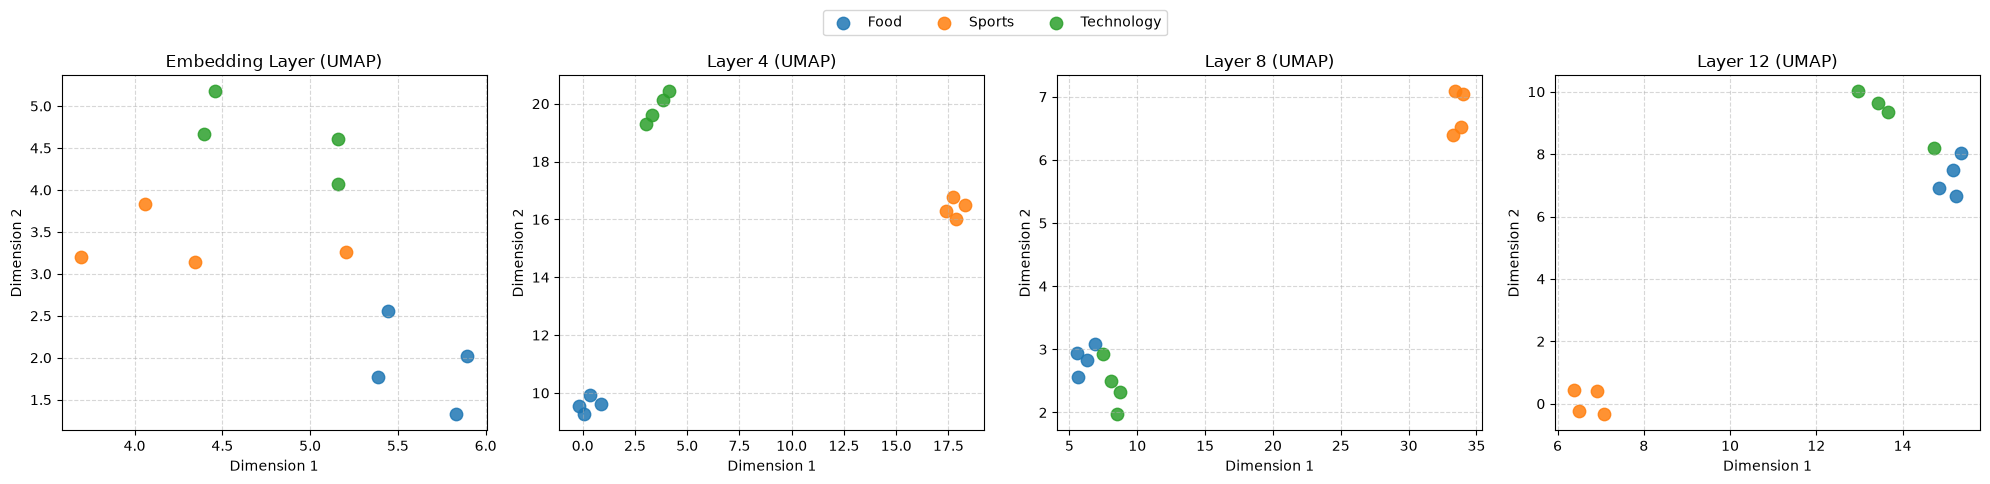

In [7]:
# ---------------------------------------------------------
# 4. Dimension Reduction (t-SNE or UMAP) Layer-by-Layer
# ---------------------------------------------------------
# Select layers to plot (e.g., Layer 0, Layer 4, Layer 8, Layer 12)
layers_to_plot = [0, 4, 8, num_layers - 1]

fig, axes = plt.subplots(1, len(layers_to_plot), figsize=(20, 4.5))

for idx, layer_num in enumerate(layers_to_plot):
    features = layer_representations[layer_num]

    if REDUCTION_METHOD.lower() == "tsne":
        reducer = TSNE(n_components=2, perplexity=3, random_state=42, n_iter=1000)
        coords = reducer.fit_transform(features)
    else:
        reducer = umap.UMAP(n_neighbors=3, min_dist=0.1, random_state=42)
        coords = reducer.fit_transform(features)

    ax = axes[idx]
    for label_id, label_name in enumerate(unique_labels):
        mask = (y_labels == label_id)
        ax.scatter(coords[mask, 0], coords[mask, 1], label=label_name, s=80, alpha=0.85)

    title = "Embedding Layer" if layer_num == 0 else f"Layer {layer_num}"
    ax.set_title(f"{title} ({REDUCTION_METHOD.upper()})")
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    ax.grid(True, linestyle="--", alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=3)
plt.tight_layout()
plt.show()
